In [2]:
import pandas as pd
import numpy as np
import pandas_ta as ta
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = None

from datetime import datetime, date
# from dateutil.relativedelta import relativedelta
import time
# import random

# import yfinance as yf
# import requests
# from fredapi import Fred

from statsmodels.tsa.seasonal import STL
from sktime.utils.plotting import plot_correlations
from scipy.stats import randint, uniform, loguniform
# from scipy.special import boxcox, inv_boxcox

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams["figure.autolayout"] = True

from get_data import DataMaker  # самодельная библиотека для сбора датасетов
from ml_models import *

import shap

# from sklearn.ensemble import RandomForestRegressor, StackingRegressor
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
# from sklearn.impute import SimpleImputer
# from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
# from sklearn.preprocessing import RobustScaler, StandardScaler, FunctionTransformer
# from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression

# from sklearn.metrics import r2_score, make_scorer, mean_absolute_error
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.decomposition import PCA

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, GRU, Conv1D, MaxPooling1D
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
# from tensorflow.keras import backend as K

from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')

In [2]:
dm = DataMaker(
    start_date='2018-01-01',
    end_date=date.today(),
    fred_api_key='6a6f2223ac49bf0fbb489f73a509bb18'
)

In [5]:
# api yahoo finance стало работать с переменным успехом, из-за чего была необходимость в доп. ф-ии

def fetch_all_binance_btc(
        start_date="2018-01-01", 
        end_date=None, 
        interval: str='1d'
):
    """
    собирает данные с официального api биржи Binance
    способна собирать информацию по большинству активов. используем для сбора данных по BTC

    `start_date`: str, начальная дата
    `end_date`: str, последняя дата
    `interval`: str, частота данных ('1h', '1d', '1w') 
    """
    if end_date is None:
        end_date = datetime.now().strftime("%Y-%m-%d")
    
    start_timestamp = int(pd.Timestamp(start_date).timestamp() * 1000)
    end_timestamp = int(pd.Timestamp(end_date).timestamp() * 1000)

    url = "https://api.binance.com/api/v3/klines"
    all_data = []

    while start_timestamp < end_timestamp:
        
        time.sleep(3)

        params = {
            "symbol": "BTCUSDT",
            "interval": interval,
            "startTime": start_timestamp,
            "endTime": end_timestamp,
            "limit": 1000  
        }

        response = requests.get(url, params=params)
        data = response.json()

        if not data:
            break  

        all_data.extend(data)

        last_candle_time = data[-1][0]
        start_timestamp = last_candle_time + 1

        last_date = pd.to_datetime(last_candle_time, unit="ms").strftime("%Y-%m-%d")
        print(f"Fetched data up to {last_date}")

    columns = [
        "Open time", "Open", "High", "Low", "Close", "Volume",
        "Close time", "Quote volume", "Trades",
        "Taker buy base volume", "Taker buy quote volume", "Ignore"
    ]
    df = pd.DataFrame(all_data, columns=columns)

    df["Date"] = pd.to_datetime(df["Open time"], unit="ms")
    df = df[["Date", "Open", "High", "Low", "Close", "Volume", "Taker buy base volume", "Taker buy quote volume"]]

    numeric_cols = ["Open", "High", "Low", "Close", "Volume", "Taker buy base volume", "Taker buy quote volume"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    df = df.drop_duplicates(subset=["Date"]).sort_values("Date")

    return df

day = pd.read_csv(
        'day_df.csv', 
        parse_dates=['Date'], 
        index_col=['Date']
    )

btc_day = fetch_all_binance_btc(
    start_date=day.index.min().strftime('%Y-%m-%d')
)

btc_day['SMA_50']  = ta.sma(btc_day['Close'], length=50)
btc_day['EMA_20']  = ta.ema(btc_day['Close'], length=20)
btc_day['EMA_100'] = ta.ema(btc_day['Close'], length=100)
btc_day['TEMA_20'] = ta.tema(btc_day['Close'], length=20)
btc_day['KAMA_20'] = ta.kama(btc_day['Close'], length=20, pow1=2, pow2=30)

btc_day = btc_day[~btc_day.EMA_100.isna()][[
    'Date', 'SMA_50', 'EMA_20', 
    'EMA_100', 'TEMA_20', 'KAMA_20',
    "Taker buy base volume", 
    "Taker buy quote volume"
]
    ].set_index('Date')

Fetched data up to 2020-10-27
Fetched data up to 2023-07-24
Fetched data up to 2025-05-10


In [12]:
daily_features = [
    "BTC",
    "BTC_lag1", "BTC_lag5", "BTC_lag10",
    "EMA_20", "SMA_50", "EMA_100",
    "MACD", "ATR", "RSI",
    "ETH", "Feer_Greed_value",
    "S&P_500", "VIX",
    "day_of_week",
    "Taker buy base volume", 
    "Taker buy quote volume"
]


hourly_features = [
    "BTC",
    "BTC_lag1", "BTC_lag2", "BTC_lag5", "BTC_lag12", "BTC_lag24",
    "EMA_10", "EMA_50",
    "MACD", "ATR", "RSI",
    "ETH",
    "OBV",
    "day_of_week", "hour_of_day"
]




In [11]:
pd.read_csv(
    'week_df.csv', 
    parse_dates=['Date'], 
    index_col=['Date']
)

,BTC,Apple,Cardano,Adobe,AMD,Amazon,ARKK_ETF,ARK_NextGen_Internet_ETF,AUD/USD,Bitcoin_Cash,Brent_Oil,USD/CHF,WTI,Dogecoin,Ethereum_Classic,ETH,EUR/USD,GBP/USD,Gold,Google,Copper,Intel,USD/JPY,Chainlink,Litecoin,Marathon_Digital,Meta,Microsoft,MicroStrategy,Natural_Gas,NVIDIA,Platinum,Invesco_QQQ,Riot_Blockchain,Silver,VanEck_Semiconductor_ETF,iShares_Semiconductor_ETF,TRON,Tesla,USD/CAD,Tether,SPDR_Materials,SPDR_Energy,SPDR_Financials,SPDR_Industrials,SPDR_Tech,Stellar,SPDR_RealEstate,SPDR_HealthCare,SPDR_Consumer_Discretionary,XRP,Dow_Jones,S&P_500,NASDAQ_100,VIX,Unemployment_Rate,Non_Farm_Payrolls,Initial_Jobless_Claims,CPI,PCE_Price_Index,Consumer_Confidence_Index,Retail_Sales,Housing_Starts,Building_Permits,M2_Money_Supply,Real_Interest_Rate,Fed_Funds_Rate,Reverse_Repo_Volume,Brent,Debt,Real_GDP,Feer_Greed_value,BTC_Supply,month,quarter,year
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-02-05,7857.69,38.26,0.43,196.98,12.80,71.79,37.81,42.06,0.80,1268.69,68.94,1.07,65.26,0.00,23.53,921.01,1.24,1.41,1336.80,56.57,3.18,39.72,0.01,0.50,148.95,11.88,188.54,85.79,13.66,3.05,5.86,998.50,158.24,13.23,16.81,48.72,56.01,0.04,23.09,1.24,0.99,52.99,53.27,25.71,69.45,62.28,0.42,24.78,78.00,99.13,0.92,25785.37,2788.71,6824.44,16.04,4.10,148054.00,224000.00,249.53,101.20,99.70,484031.00,1277.00,1321.00,13919.30,0.67,1.42,59.01,67.69,21089643.00,20044.08,24.00,16844437.50,2,1,2018
2018-02-12,10148.71,36.83,0.37,188.45,11.36,67.58,35.91,40.13,0.78,1148.53,63.95,1.07,60.47,0.00,22.24,780.28,1.23,1.39,1319.22,52.31,3.08,37.19,0.01,0.40,143.56,10.06,176.67,81.70,13.13,2.66,5.61,967.00,149.55,14.73,16.26,45.92,52.88,0.04,21.07,1.26,1.00,50.59,48.88,24.18,65.56,59.18,0.37,23.73,73.20,94.27,0.97,24315.65,2633.79,6449.44,31.30,4.10,148054.00,225000.00,249.53,101.20,99.70,484031.00,1277.00,1321.00,13919.30,0.79,1.42,30.63,62.20,21089643.00,20044.08,35.00,16859112.50,2,1,2018
2018-02-19,10173.76,39.95,0.39,198.89,11.92,71.38,37.75,42.66,0.79,1455.51,64.16,1.08,60.89,0.01,32.63,912.07,1.24,1.40,1346.45,54.05,3.20,38.40,0.01,0.68,204.86,10.70,175.94,84.44,13.59,2.57,5.95,999.42,155.52,12.97,16.65,47.64,54.88,0.05,22.01,1.26,1.01,51.97,49.14,24.95,67.61,61.72,0.44,23.86,74.97,96.82,1.12,25040.42,2710.33,6701.56,21.51,4.10,148054.00,219000.00,249.53,101.20,99.70,484031.00,1277.00,1321.00,13919.30,0.78,1.42,29.61,64.95,21089643.00,20044.08,61.71,16873762.50,2,1,2018
2018-02-26,11013.78,41.15,0.35,207.11,11.99,74.37,38.68,43.89,0.79,1267.07,66.60,1.07,62.89,0.01,37.03,862.42,1.23,1.40,1332.15,55.76,3.21,39.86,0.01,0.70,219.73,9.92,180.42,86.68,13.79,2.62,6.08,996.55,159.25,10.62,16.50,49.03,56.33,0.04,23.18,1.26,1.00,52.65,49.40,25.25,68.26,63.01,0.38,23.95,75.26,98.20,0.99,25181.72,2735.03,6857.80,17.76,4.10,148054.00,216000.00,249.53,101.20,99.70,484031.00,1277.00,1321.00,13919.30,0.73,1.42,9.36,67.96,21089643.00,20044.08,44.57,16881100.00,2,1,2018
2018-03-05,9843.60,41.62,0.31,208.69,11.98,74.80,38.75,43.90,0.78,1257.81,64.96,1.06,61.72,0.01,31.37,867.47,1.23,1.39,1321.12,54.27,3.12,41.38,0.01,0.63,215.89,8.75,177.14,86.58,12.79,2.68,5.84,970.57,158.26,10.39,16.38,49.71,57.21,0.05,22.55,1.28,1.00,51.35,48.74,24.87,66.94,62.92,0.35,23.58,74.40,96.43,0.98,24773.56,2704.74,6817.56,20.17,4.00,148280.00,228000.00,249.58,101.42,101.40,484110.00,1318.00,1385.00,13976.00,0.75,1.51,15.23,65.78,21089643.00,20044.08,46.43,16895800.00,3,1,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-07,81955.46,197.43,0.60,358.74,89.85,176.58,43.48,88.33,0.61,281.45,67.66,1.16,64.18,0.16,14.85,1661.02,1.10,1.30,3050.90,148.75,4.56,20.83,0.01,11.98,74.39,11.27,524.08,366.06,293.00,3.93,98.18,928.78,436.89,7.19,30.59,189.11,165.47,0.23,249.96,1.42,1.00,80.14,82.62,45.71

In [5]:
day = (
    pd.read_csv(
        'day_df.csv', 
        parse_dates=['Date'], 
        index_col=['Date']
    ).merge(
        btc_day, left_index=True, right_index=True
    )
)
day = day[daily_features]

day.head()

,BTC,BTC_lag1,BTC_lag5,BTC_lag10,EMA_20,SMA_50,EMA_100,MACD,ATR,RSI,ETH,Feer_Greed_value,S&P_500,VIX,day_of_week,Taker buy base volume,Taker buy quote volume
Date,,,,,,,,,,,,,,,,,
2018-05-11,8582.60,9264.18,9843.98,9281.26,9060.61,8277.78,8842.49,274.86,405.39,50.52,736.99,41.00,2719.20,13.25,4,22767.46,197915875.75
2018-05-12,8474.53,9131.11,9678.75,9096.24,9003.98,8269.14,8835.03,185.81,423.47,42.47,691.49,44.00,2726.44,12.85,5,19545.97,164142437.42
2018-05-13,8654.14,8582.60,9410.85,9185.87,8973.09,8271.80,8831.95,118.99,424.75,43.49,676.89,40.00,2726.44,12.85,6,12797.05,109577063.57
2018-05-14,8670.67,8474.53,9265.04,9618.55,8943.59,8275.66,8828.62,82.75,421.44,46.99,720.91,40.00,2726.44,12.85,0,18408.06,157869523.77
2018-05-15,8578.35,8654.14,9264.18,9691.67,8897.73,8282.22,8821.36,52.85,427.99,46.89,724.76,40.00,2731.96,12.99,1,13977.50,120464422.62


In [76]:
week = pd.read_csv(
            'week_df.csv', 
            parse_dates=['Date'], 
            index_col=['Date']
        )   
week['BTC_lag1'] = week.BTC.shift(2)

weekly_features = [
    "BTC",
    "BTC_lag1",
    # "SMA_50",
    "SMA_2",
    "EMA_4",
    "ETH",
    "Fed_Funds_Rate",
    "CPI", "Gold",
    "VIX",
    "Taker buy base volume", 
    "Taker buy quote volume"
]

btc_week = fetch_all_binance_btc(
    start_date=week.index.min().strftime('%Y-%m-%d'),
    interval='1w'
)
# btc_week['SMA_50']  = ta.sma(btc_week['Close'], length=50)
btc_week['SMA_2']  = ta.sma(btc_week['Close'], length=2).shift()
btc_week['EMA_4']  = ta.ema(btc_week['Close'], length=4).shift()

btc_week = btc_week[~btc_week.EMA_4.isna()][[
                        'Date', 'SMA_2', 'EMA_4',
                        "Taker buy base volume", 
                        "Taker buy quote volume"
                    ]
                        ].set_index('Date')
week = week.merge(
            btc_week, left_index=True, right_index=True
        )
week = week[weekly_features]

Fetched data up to 2025-05-05


In [77]:
X_week, y_week = week.drop(columns=['BTC']), week['BTC']

In [78]:
ridge_week = LinearForecaster(
    test_size=52,
    model_type='Ridge'
)
ridge_week.fit(X_week, y_week)


lasso_week = LinearForecaster(
    test_size=52,
    model_type='Lasso'
)
lasso_week.fit(X_week, y_week)


elastic_week = LinearForecaster(
    test_size=52,
    model_type='ElasticNet'
)
elastic_week.fit(X_week, y_week)


[2025-05-10 08:15:23] Starting Ridge training



[2025-05-10 08:15:58] Finished Ridge training

[2025-05-10 08:15:58] Starting Lasso training

[2025-05-10 08:16:02] Finished Lasso training

[2025-05-10 08:16:02] Starting ElasticNet training

[2025-05-10 08:18:26] Finished ElasticNet training


LinearForecaster(model_type='ElasticNet')

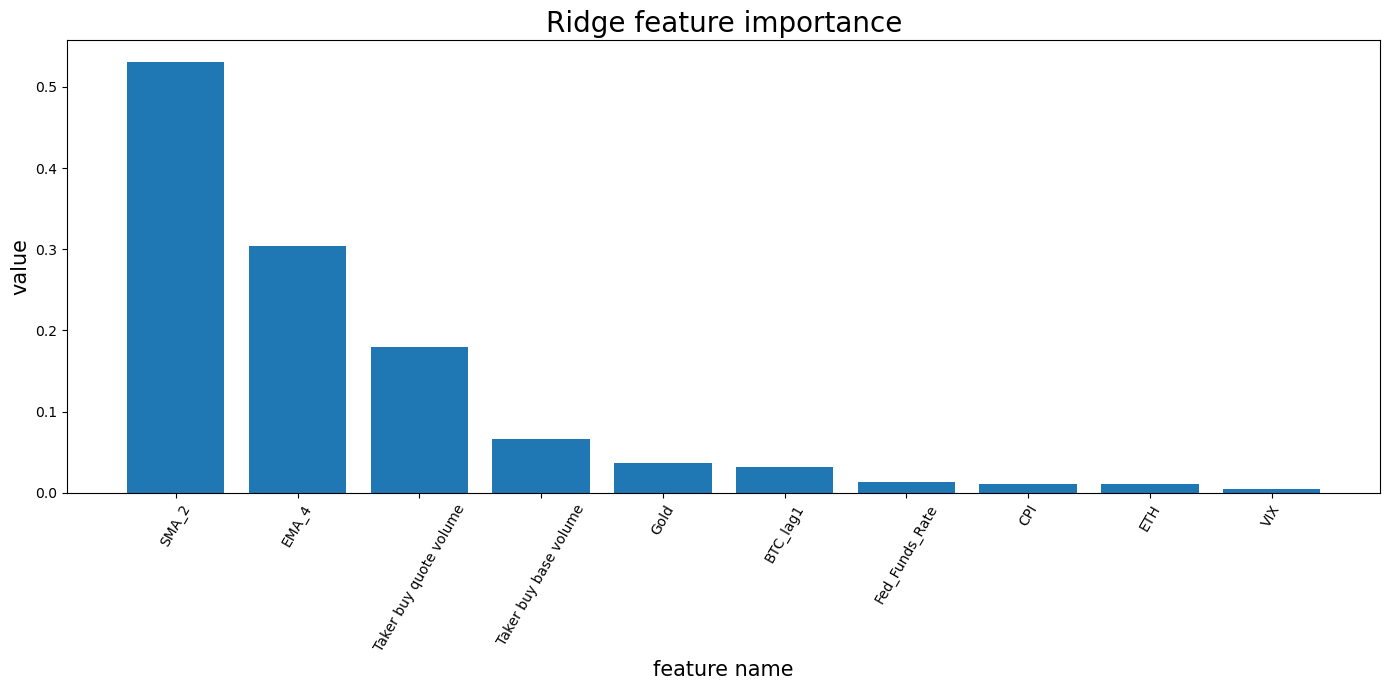

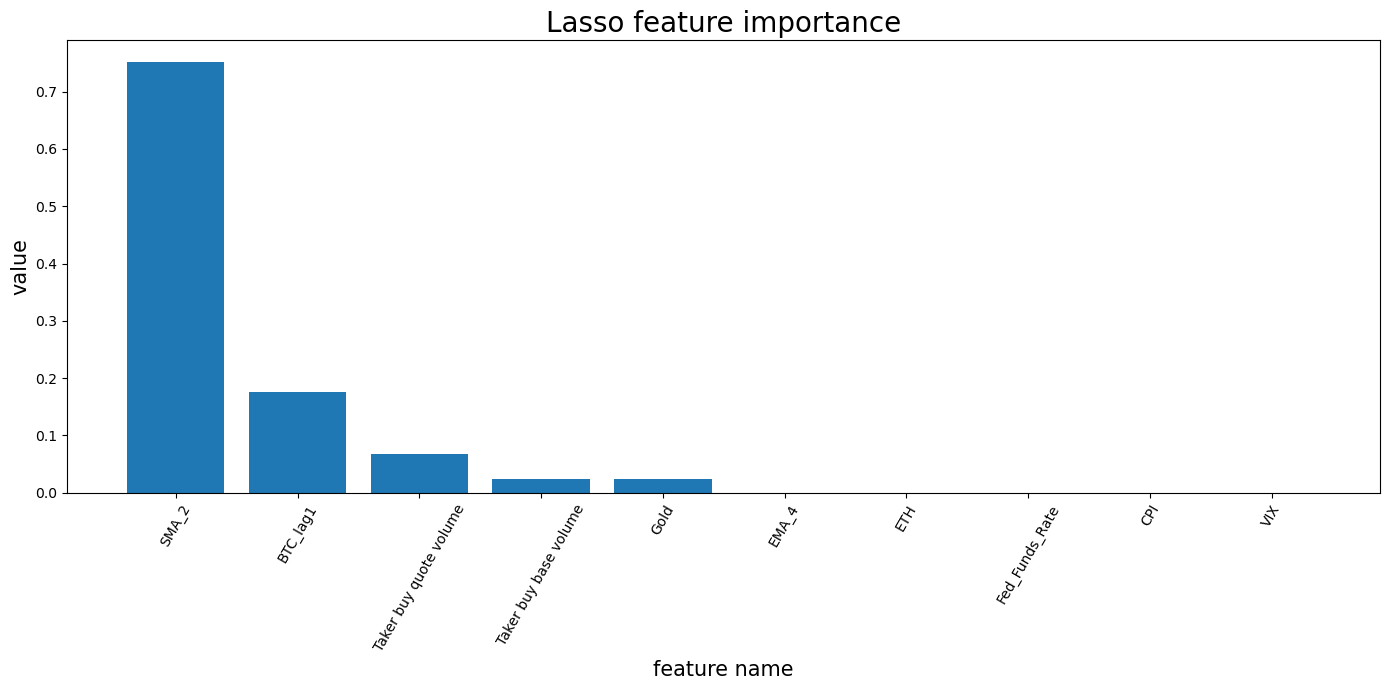

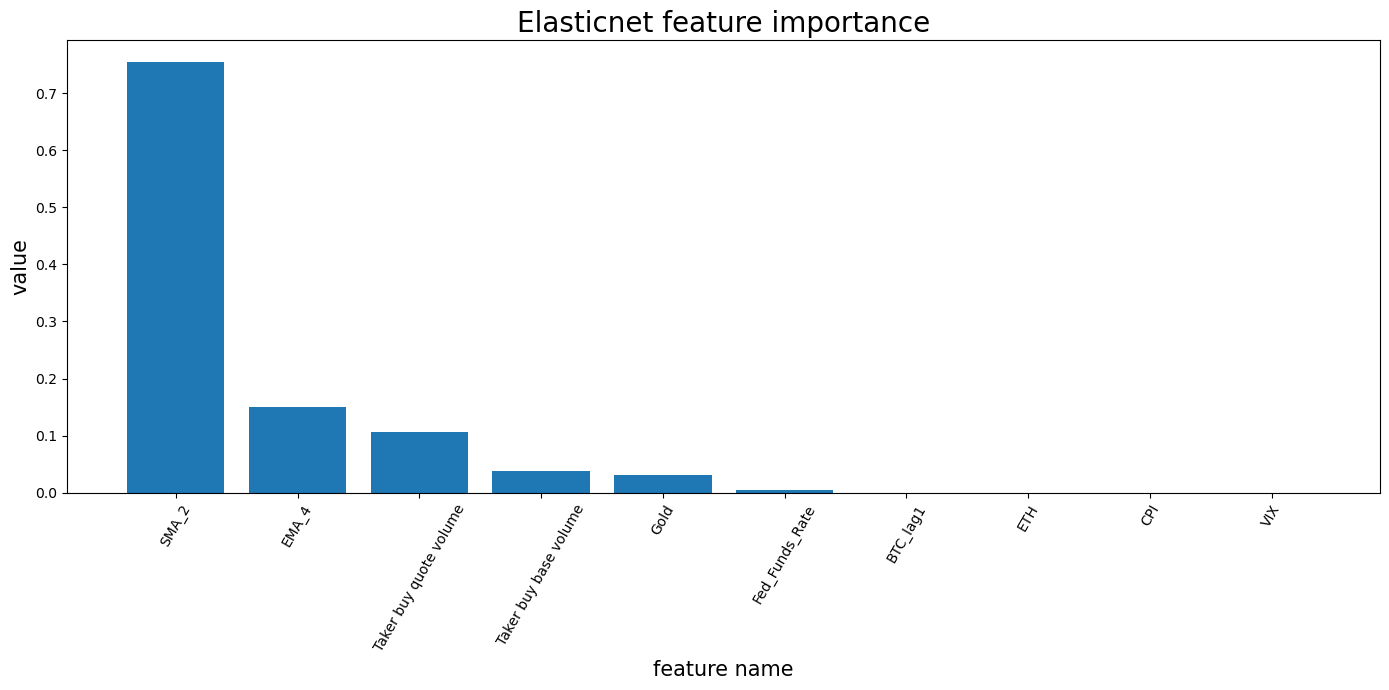

In [79]:
def get_feature_importance(model, X: pd.DataFrame, top_n: int=None, make_plot: bool=True, ):
    """
    
    """
    feature_names = X.columns.tolist()

    lin_feature_importance = pd.DataFrame({
                                    'feature_names': feature_names,
                                    'feature_importance': np.abs(model.model_.best_estimator_.regressor_.named_steps['reg'].coef_)
                                }).sort_values(
                                    by='feature_importance', 
                                    ascending=False, 
                                    ignore_index=True
                                )
    
    if top_n is not None:
        lin_feature_importance = lin_feature_importance.head(top_n)
    
    if make_plot:

        plt.figure(figsize=(14, 7))
        plt.bar(
            x=lin_feature_importance['feature_names'], 
            height=lin_feature_importance['feature_importance']
        )

        plt.title(f'{model.model_type.capitalize()} feature importance', fontsize=20)
        plt.ylabel('value', fontsize=15)
        plt.xlabel('feature name', fontsize=15)

        plt.xticks(rotation=60)
        
        plt.show();

    return lin_feature_importance

ridge_feature_importance    = get_feature_importance(model=ridge_week,   X=X_week)
lasso_feature_importance    = get_feature_importance(model=lasso_week,   X=X_week)
elastic_feature_importance  = get_feature_importance(model=elastic_week, X=X_week)

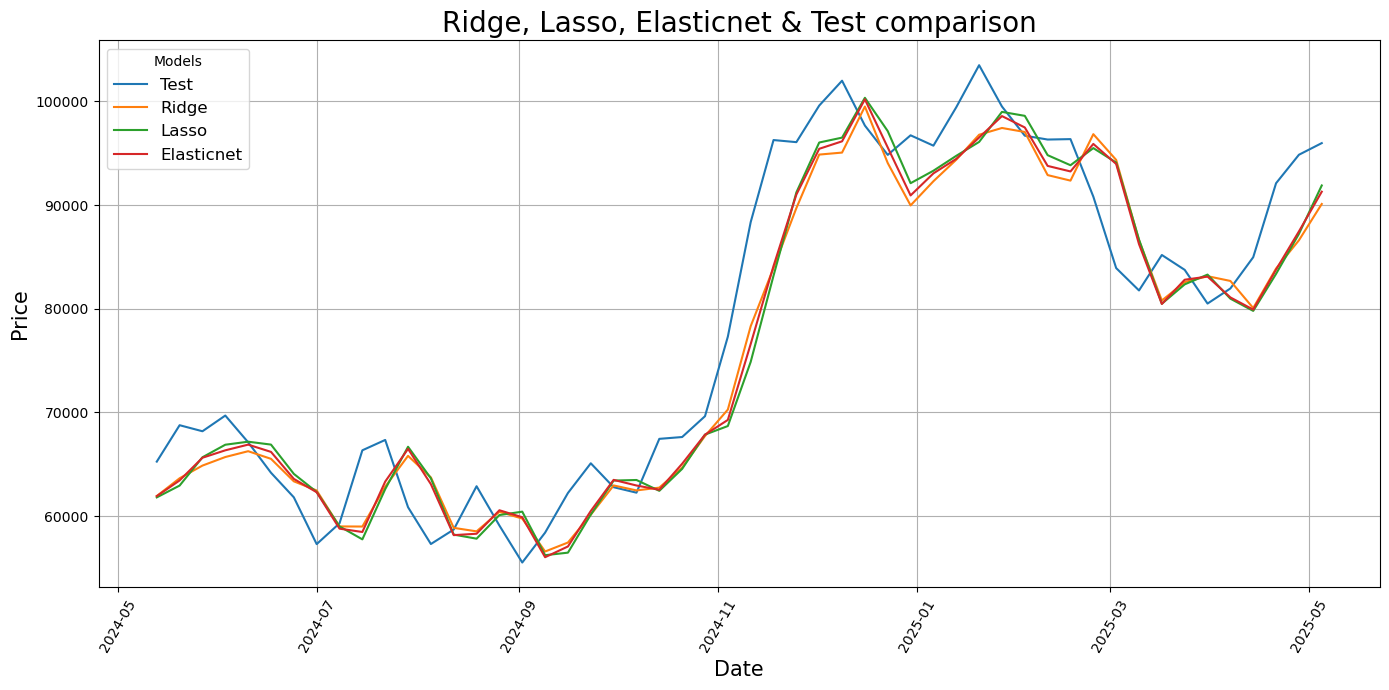

In [80]:
def make_plot(y, models, figsize: tuple=(14, 7)):
    """
    визуализация предсказаний

    `y`: тестовый таргет
    `models`: список моделей для визуализации
    `figsize`: размер изображения
    """
    if not isinstance(models, list): 
        models=[models]

    plt.figure(figsize=figsize)

    plt.plot(y.iloc[-models[0].test_size:], label='Test')

    for model in models:
        plt.plot(model.result_.y_pred, label=f'{model.model_type.capitalize()}')

    plt.title(f"{', '.join([model.model_type.capitalize() for model in models])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date', fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)


make_plot(y=y_week, models=[ridge_week, lasso_week, elastic_week])

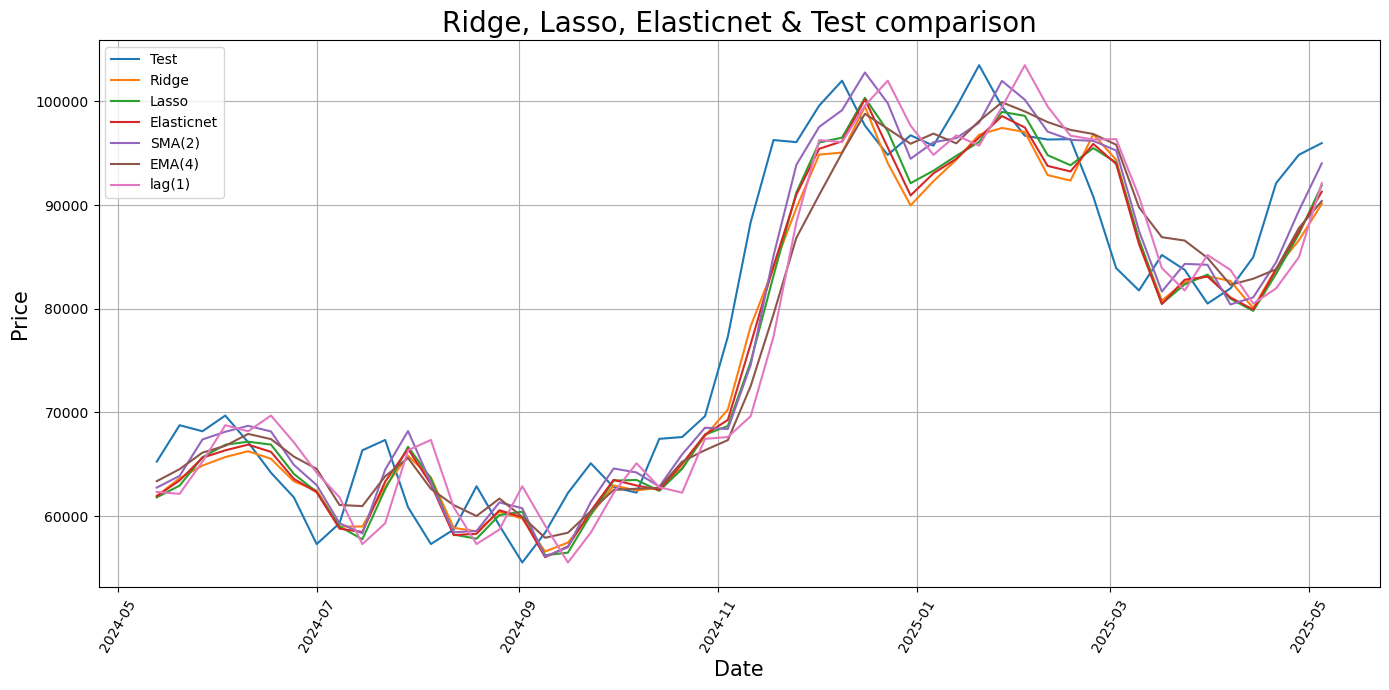

In [87]:
make_plot(y=y_week, models=[ridge_week, lasso_week, elastic_week])

plt.plot(week.SMA_2.iloc[-52:], label='SMA(2)')
plt.plot(week.EMA_4.iloc[-52:], label='EMA(4)')
plt.plot(week.BTC_lag1.iloc[-52:], label='lag(1)')

plt.legend();

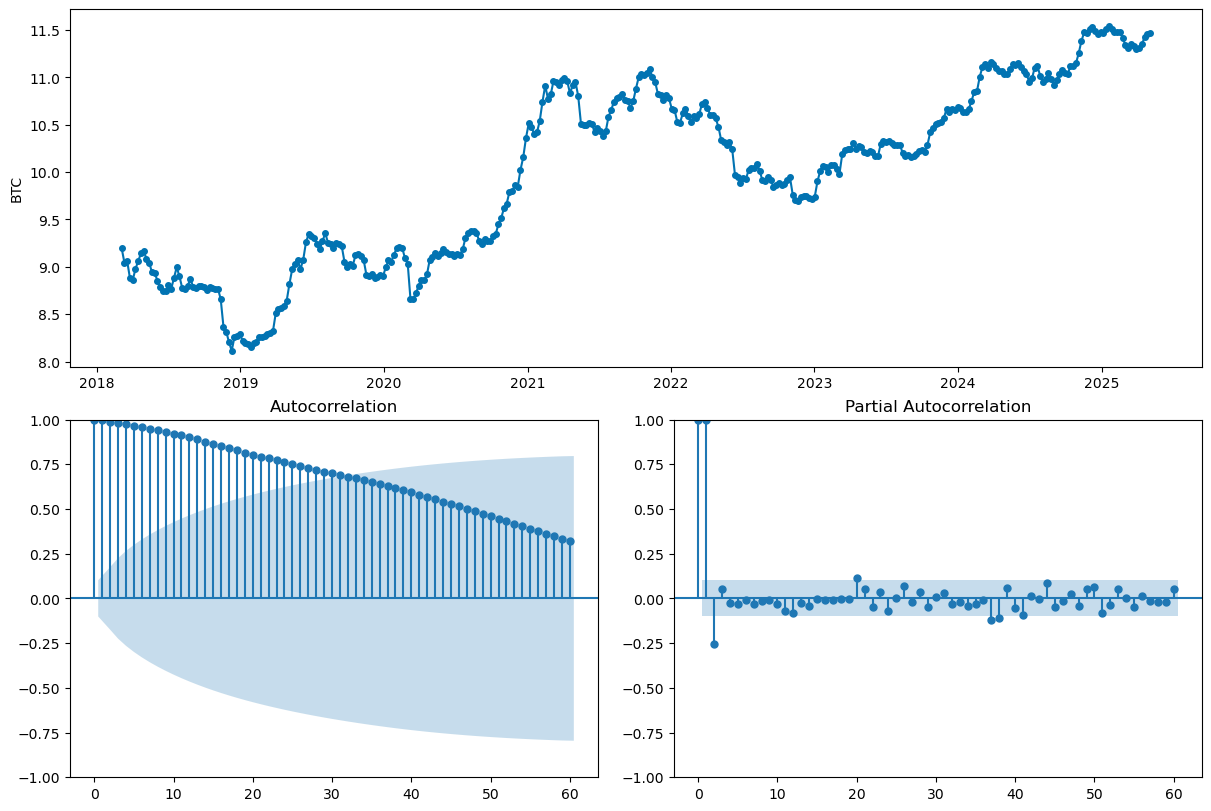

In [82]:
plot_correlations(np.log1p(week.BTC), lags=60);